In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
train = pd.read_csv("train_binary.csv")
test = pd.read_csv("test_binary.csv")

print(train.head())
print(test.head())
X = train.drop(columns=[ 'label']).values
y = train['label'].values
X_test=test


    feature_0  feature_1    feature_2   feature_3  feature_4     feature_5  \
0  515.552122   0.501142  5333.319937  172.962979   0.004575  46549.221548   
1  668.286985   0.508581  4370.282875  128.300296   0.004639  44025.018827   
2  517.168489   0.483042  3326.280886   75.704752   0.004040  52406.140385   
3  417.096784   0.487056  6286.092355  102.207298   0.004742  36243.588753   
4  427.939556   0.498989  3768.307841  124.954769   0.004527  45977.266327   

    feature_6  feature_7    feature_8   feature_9  ...  feature_16  \
0  502.584920   0.458395  4625.879935  151.521484  ...  144.258303   
1  636.168692   0.467422  3879.914621  107.274618  ...   62.304522   
2  492.702393   0.444783  2869.670905   60.559518  ...  111.695965   
3  397.695808   0.447867  5592.085691   81.986835  ...   35.834294   
4  417.109675   0.460051  3413.620214   88.142404  ...   71.319597   

   feature_17   feature_18  feature_19  feature_20   feature_21  feature_22  \
0    0.789506  2865.992302  160

In [3]:
np.random.seed(42)

n = X.shape[0]
idx = np.random.permutation(n)

split = int(0.8 * n)
train_idx = idx[:split]
val_idx   = idx[split:]

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]


In [4]:
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0) 

X_train = (X_train - X_mean) / X_std
X_val   = (X_val   - X_mean) / X_std
X_test  = (X_test  - X_mean) / X_std



In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
def predict(X, w, b):
    z = np.dot(X, w) + b
    h = sigmoid(z)
    return (h >= 0.5).astype(int) # threshold → gives 0 or 1


def compute_cost(X, y, w, b,lambda_):
    m,n = X_train.shape
    z =np.dot(X,w) + b
    g = sigmoid(z)
    cost = -(1/m) * np.sum(y*np.log(g) + (1-y)*np.log(1-g))
    reg=(lambda_)/(2*m)*np.sum(w**2)
    return cost+reg

In [6]:
def compute_gradient(X, y, w, b,lambda_):
    m,n = X_train.shape
    z =X.dot(w)+ b
    g = sigmoid(z)
    dw = (1/m) *(X.T@(g-y))+(lambda_/m)*w
    db = (1/m) * np.sum(g- y)
    return dw, db

In [7]:
def gradient_descent(X, y, w, b, alpha=0.001, iterations=1000,lambda_=0.01):
    cost_history = []

    for i in range(iterations):
        # compute gradients
        dw, db = compute_gradient(X_train, y_train, w, b,lambda_)

        # update parameters
        w -= alpha * dw       # dw is (3072,)
        b -= alpha * db       # db is scalar (correct)

        # store cost
    #if i % 100 == 0:
        cost = compute_cost(X_train, y_train, w, b,lambda_)
        cost_history.append(cost)

    return w, b, cost_history

In [8]:
m,n=X_train.shape
w=np.zeros(n)
b=0
alpha=0.001
iterations=1000
lambda_=0
w,b,cost_history=gradient_descent(X_train,y_train,w,b,alpha,iterations,lambda_)
print("Final weights of w",w)
print("Final weights of b",b)
print("Final cost",cost_history[-1])


Final weights of w [ 1.29009780e-01 -9.62433589e-02 -7.26509404e-04  1.62524529e-03
 -7.03366883e-04 -1.42873918e-03  1.28374450e-01 -9.40129739e-02
 -5.49743017e-04  1.72302338e-03  1.39458909e-02 -9.86324898e-04
  1.02665654e-01  1.30328495e-03 -1.00033978e-01  3.73172517e-03
  7.34930192e-04 -2.09325394e-04  1.19347955e-03  2.63799848e-01
  2.73442946e-01 -2.77508410e-01  2.82959812e-02  2.62109642e-02
 -1.35904543e-01]
Final weights of b -0.17195942454025562
Final cost 0.3322189114087738


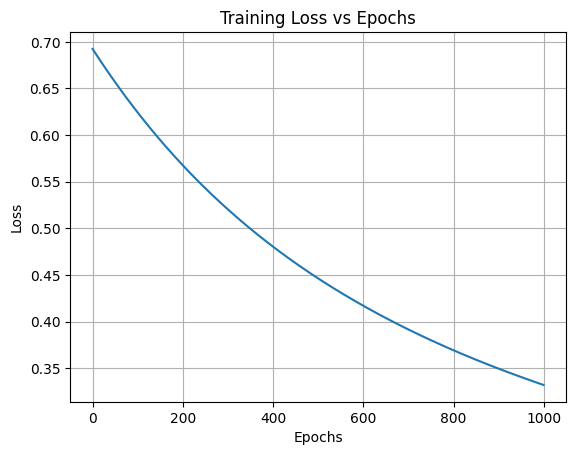

In [9]:
import matplotlib.pyplot as plt

plt.plot(cost_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.grid(True)
plt.show()



In [10]:
preds = predict(X_test, w, b)

# Show first 10 outputs
print(preds[:20])


[0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [11]:
y_pred_val = predict(X_val, w, b)
accuracy = np.mean(y_pred_val == y_val)
print("Cross validation Accuracy:", accuracy)


Cross validation Accuracy: 0.9861


In [12]:
logistic = pd.DataFrame({
    
    "label": preds
})

logistic.to_csv("logistic.csv", index=False)
print("logistic.csv created!")


logistic.csv created!
